# 03 · A mesma rede em PyTorch

Em Keras, `fit()` esconde o laço de treino. Em PyTorch ele fica à vista, como no exercício
da Iris: para cada mini-lote, **zerar gradientes → forward → perda → backward → passo do
otimizador**. A arquitetura é a mesma do notebook 02 (64 → 32 → 16, Dropout 0,2, Adam),
para comparar os dois frameworks em igualdade de condições.

Diferença técnica: a última camada devolve um **logit** (sem sigmoide) e a perda é
`BCEWithLogitsLoss`, que junta sigmoide e entropia cruzada de forma numericamente mais
estável.

In [1]:
import sys
from pathlib import Path

# Permite importar `src` mesmo fora do ambiente do uv (ex.: Colab com o repositório clonado).
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import pandas as pd
import torch

from src.data.dados import preparar
from src.model import avaliacao, mlp_torch
from src.utils import graficos
from src.utils.io import configurar_estilo, salvar_figura, salvar_tabela

configurar_estilo()
SECAO = "03-mlp-pytorch"
mlp_torch.fixar_semente()
print("PyTorch", torch.__version__, "· dispositivo disponível:", mlp_torch.dispositivo())

PyTorch 2.14.0 · dispositivo disponível: mps


In [2]:
particao = preparar()
modelo = mlp_torch.CardioNet(particao.n_entradas, ocultas=(64, 32, 16), dropout=0.2)
print(modelo)
print("Parâmetros:", sum(p.numel() for p in modelo.parameters()))

CardioNet(
  (rede): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)
Parâmetros: 3713


O treino roda na CPU: com 16 entradas e 41 mil pacientes a rede é pequena, e o custo de
mover cada mini-lote para a GPU (MPS/CUDA) supera o ganho.

época   0  perda 0.5967  AUC val 0.7964


época   5  perda 0.5524  AUC val 0.8011


época  10  perda 0.5479  AUC val 0.8014


época  15  perda 0.5461  AUC val 0.8017


época  20  perda 0.5449  AUC val 0.8014


época  25  perda 0.5459  AUC val 0.8016


época  30  perda 0.5438  AUC val 0.8019


época  35  perda 0.5452  AUC val 0.8015


época  40  perda 0.5430  AUC val 0.8014


época  45  perda 0.5423  AUC val 0.8007
Épocas executadas: 46


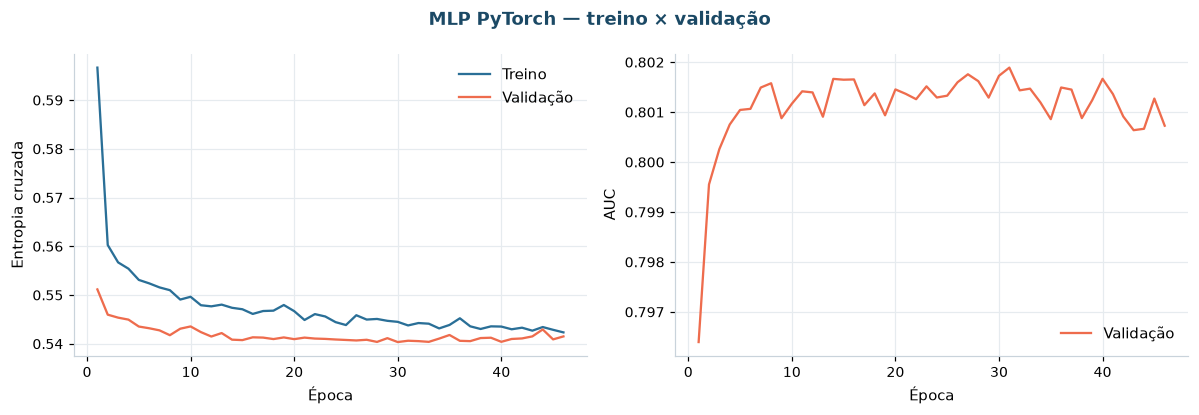

In [3]:
historico = mlp_torch.treinar(
    modelo,
    particao.X_treino, particao.y_treino,
    particao.X_val, particao.y_val,
    epocas=200, lote=256, taxa=1e-3, paciencia=15,
    disp=torch.device("cpu"), verbose=True,
)
print(f"Épocas executadas: {len(historico['perda'])}")

fig, dados = graficos.curvas_de_treino(
    {"perda": historico["perda"], "perda_val": historico["perda_val"], "val_auc": historico["auc_val"]},
    "MLP PyTorch — treino × validação",
)
salvar_figura(fig, SECAO, "curvas-treino", dados)
plt.show()

In [4]:
p_val = mlp_torch.prever(modelo, particao.X_val)
limiar = avaliacao.escolher_limiar(particao.y_val, p_val)
p_teste = mlp_torch.prever(modelo, particao.X_teste)

tabela = avaliacao.tabela_comparativa({
    "MLP PyTorch · limiar 0,50": avaliacao.metricas(particao.y_teste, p_teste, 0.5),
    f"MLP PyTorch · limiar {limiar:.2f}": avaliacao.metricas(particao.y_teste, p_teste, limiar),
})
salvar_tabela(tabela, SECAO, "metricas-teste")
tabela

,auc_roc,auc_pr,acuracia,sensibilidade,especificidade,precisao,f1,brier,limiar
"MLP PyTorch · limiar 0,50",0.801,0.7818,0.7388,0.6955,0.7813,0.7569,0.7249,0.1802,0.5000
MLP PyTorch · limiar 0.38,0.801,0.7818,0.7151,0.8109,0.6213,0.6771,0.7380,0.1802,0.3779


## Keras × PyTorch

| | Keras | PyTorch |
|:--|:--|:--|
| Definição da rede | `Sequential([...])` | classe `nn.Module` com `forward` |
| Laço de treino | `model.fit()` | escrito à mão |
| Saída | sigmoide + `binary_crossentropy` | logit + `BCEWithLogitsLoss` |
| Early stopping | callback pronto | lógica própria, guardando o `state_dict` |
| Controle | menos código | cada passo explícito e customizável |

Com a mesma arquitetura, otimizador e dados, as duas implementações chegam a AUCs
praticamente iguais — a diferença entre frameworks é de **ergonomia**, não de capacidade
de modelagem.